# Import the dataset

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [ ]:
df = pd.read_csv('/dataset/train.csv')
testdf = pd.read_csv('/dataset/test.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [4]:
testdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102000 entries, 0 to 101999
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  102000 non-null  object
 1   post_id       102000 non-null  int64 
 2   emoticon_1    102000 non-null  int64 
 3   emoticon_2    102000 non-null  int64 
 4   emoticon_3    102000 non-null  int64 
 5   upvote        102000 non-null  int64 
 6   downvote      102000 non-null  int64 
 7   if_1          102000 non-null  int64 
 8   if_2          102000 non-null  int64 
 9   race          26731 non-null   object
 10  religion      26731 non-null   object
 11  gender        26731 non-null   object
 12  disability    102000 non-null  bool  
 13  comment       102000 non-null  object
dtypes: bool(1), int64(8), object(5)
memory usage: 10.2+ MB


# Filling the Null values

In [5]:
print(f"Null values in train set:\n{df.isna().sum()}")
print(f"Null values in test set:\n{testdf.isna().sum()}")

Null values in train set:
created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64
Null values in test set:
created_date        0
post_id             0
emoticon_1          0
emoticon_2          0
emoticon_3          0
upvote              0
downvote            0
if_1                0
if_2                0
race            75269
religion        75269
gender          75269
disability          0
comment             0
dtype: int64


In [6]:
df['race'] = df['race'].fillna('Unknown')
df['religion'] = df['religion'].fillna('Unknown')
df['gender'] = df['gender'].fillna('Unknown')
df['comment'] = df['comment'].fillna('')

testdf['race'] = testdf['race'].fillna('Unknown')
testdf['religion'] = testdf['religion'].fillna('Unknown')
testdf['gender'] = testdf['gender'].fillna('Unknown')

# Visualize the dataset

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

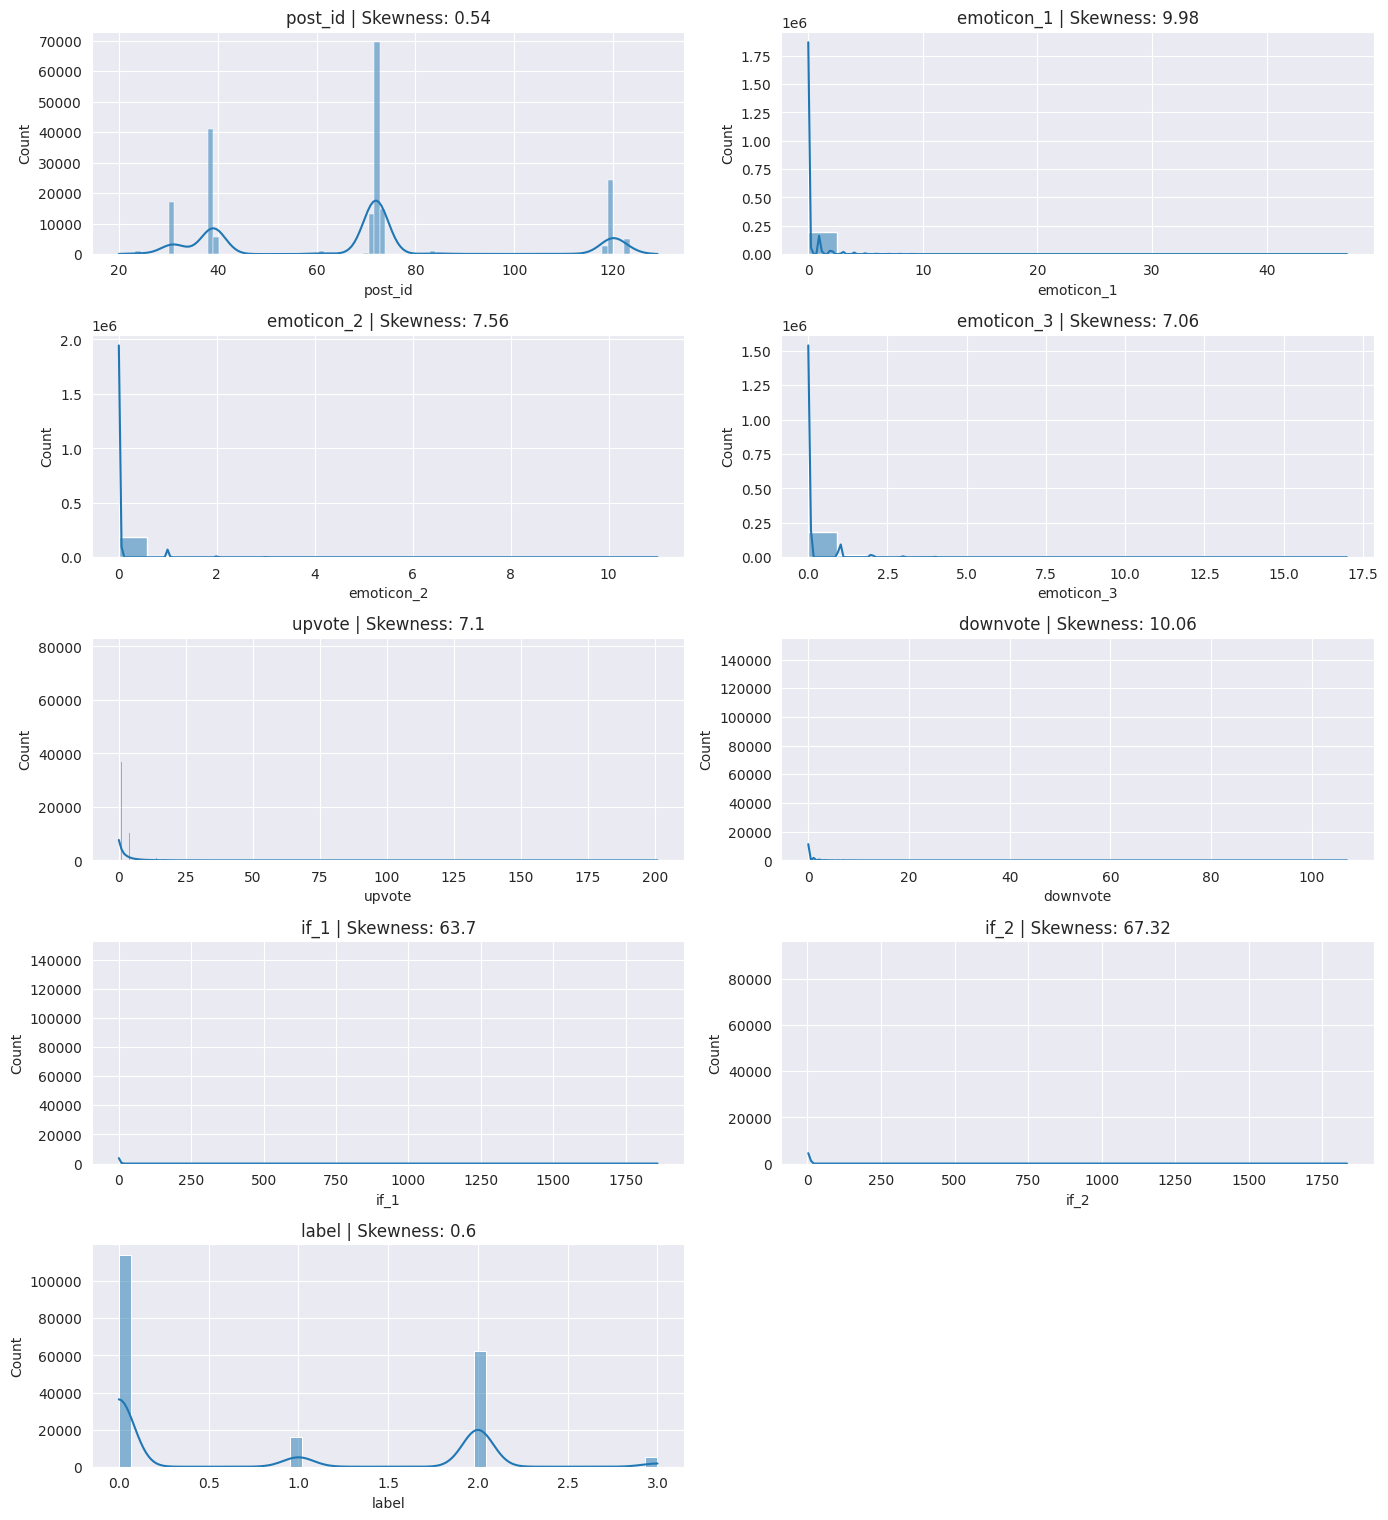

In [8]:
sns.set_style("darkgrid")

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

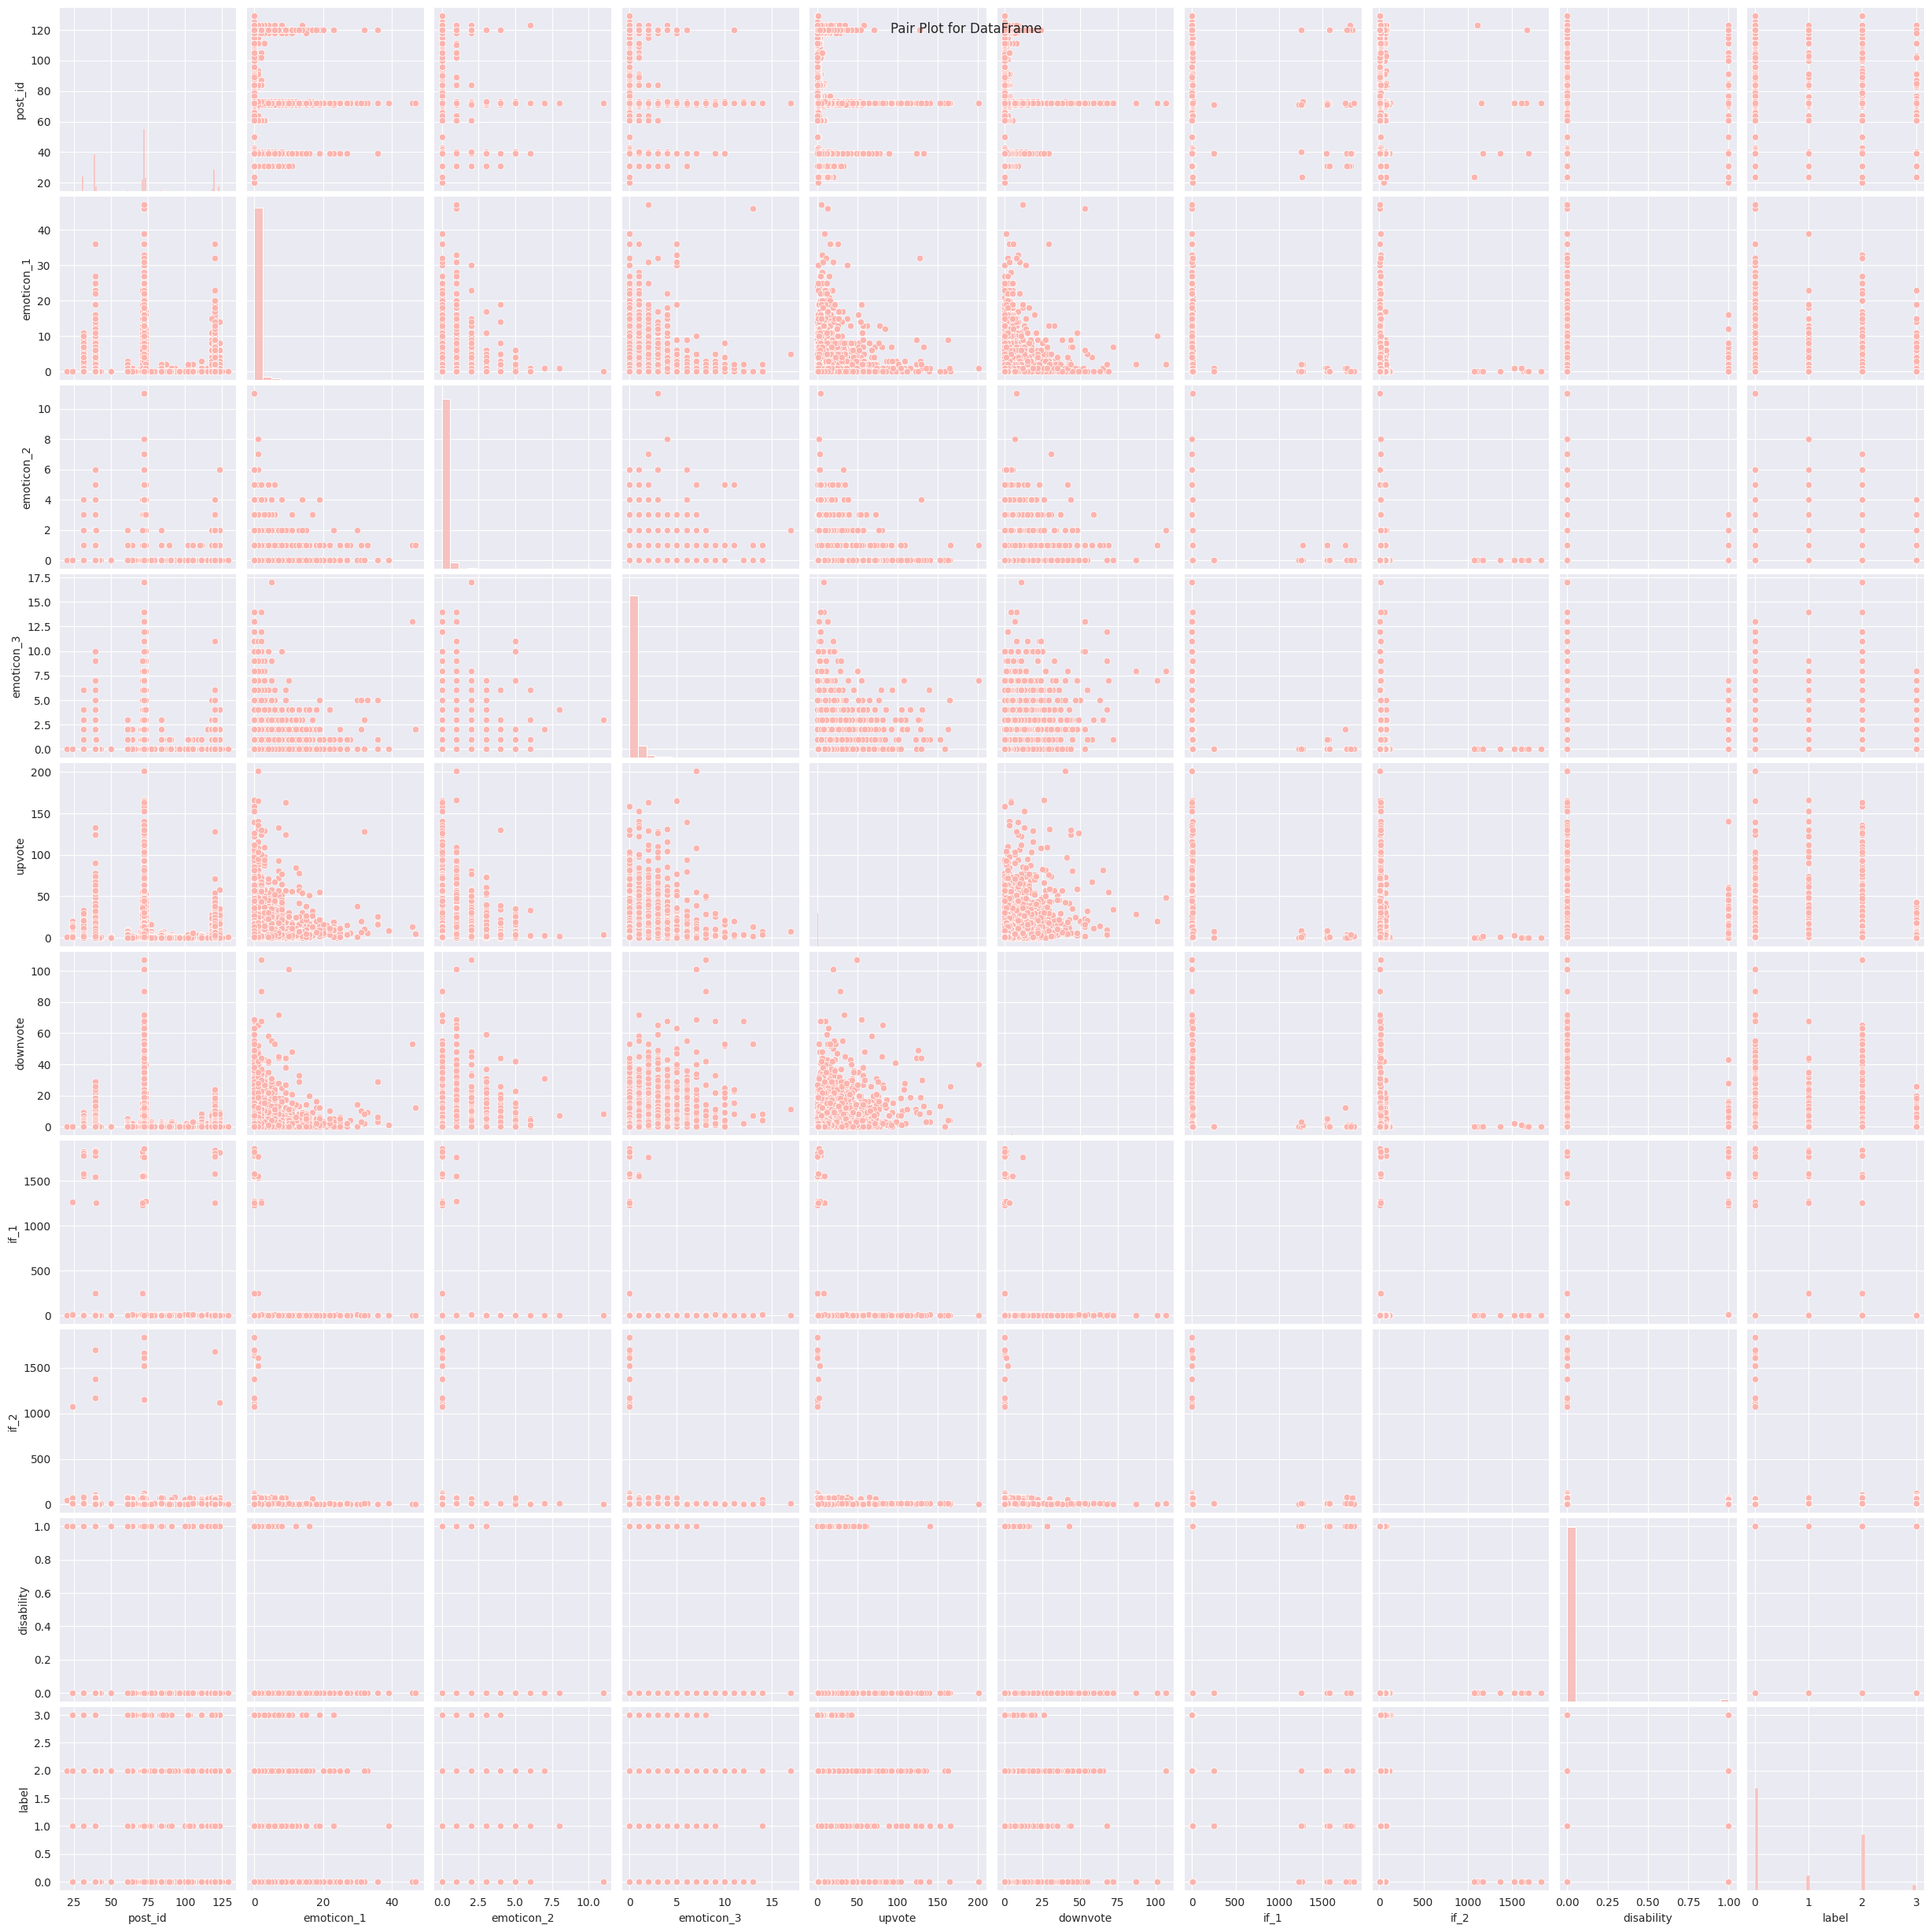

In [9]:
sns.set_palette("Pastel1")

plt.figure(figsize=(10, 6))

sns.pairplot(df)

plt.suptitle('Pair Plot for DataFrame')
plt.show()

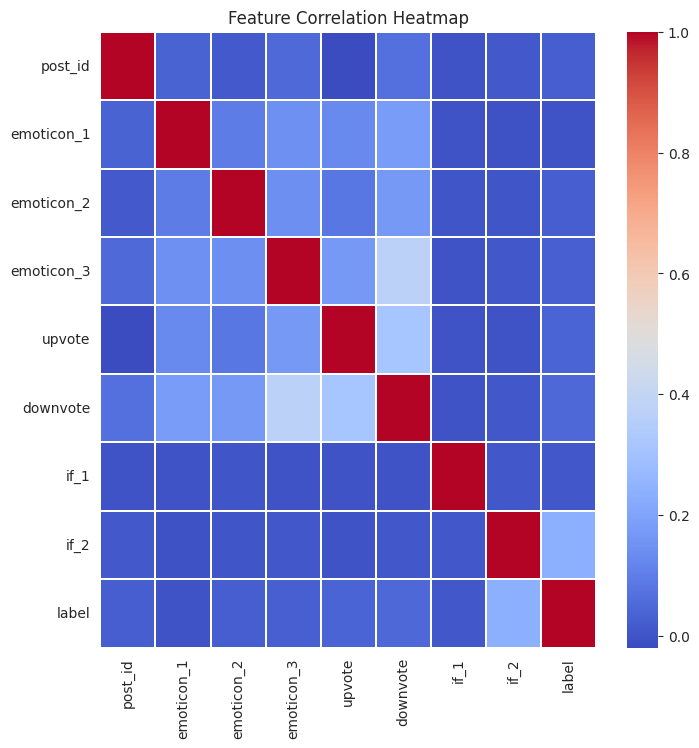

In [10]:
plt.figure(figsize=(8, 8))
sns.heatmap(df.select_dtypes(include=['number']).corr(), cmap="coolwarm", linewidths=0.2)
plt.title("Feature Correlation Heatmap")
plt.show()

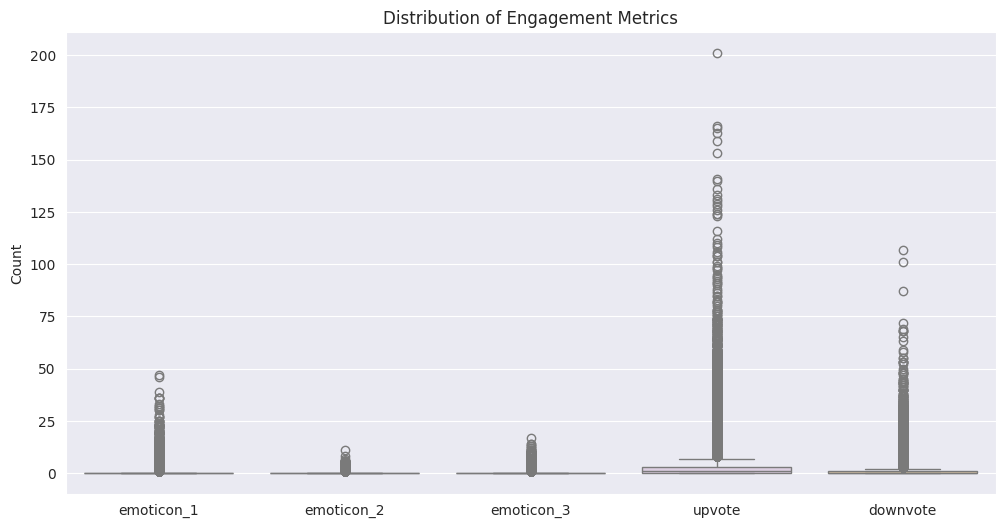

In [11]:
cols_to_plot = ['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote']

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[cols_to_plot])
plt.title('Distribution of Engagement Metrics')
plt.ylabel('Count')
plt.show()

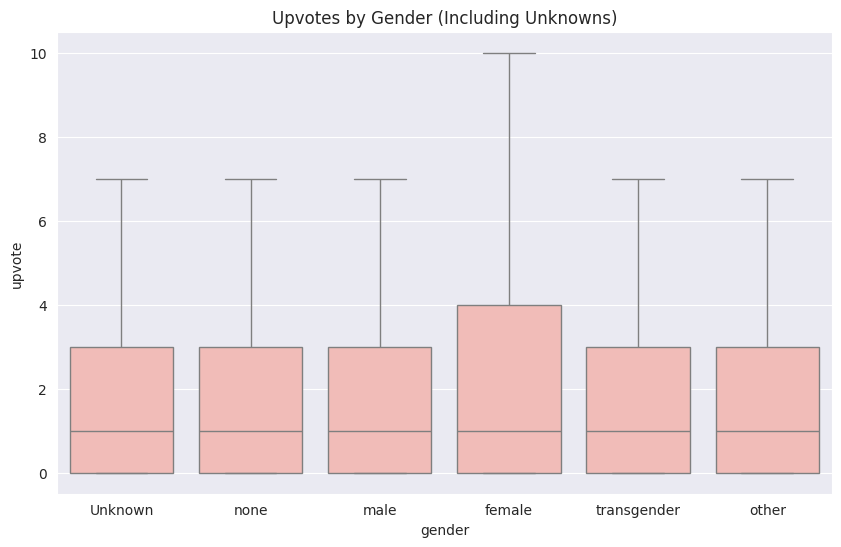

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='gender', y='upvote', data=df, showfliers=False)
plt.title('Upvotes by Gender (Including Unknowns)')
plt.show()

# Feature Extraction

In [13]:
df['created_date'] = pd.to_datetime(df['created_date'])
df['hour'] = df['created_date'].dt.hour
df['month'] = df['created_date'].dt.month_name()
df['day_of_week'] = df['created_date'].dt.dayofweek
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['total_votes'] = df['upvote'] + df['downvote']
df['total_emoticons'] = df['emoticon_1'] + df['emoticon_2'] + df['emoticon_3']
df['upvote_ratio'] = df['upvote'] / (df['total_votes'] + 1)
df['emoticon_1_ratio'] = df['emoticon_1'] / (df['total_emoticons'] + 1)
df['is_weekend'] = df['created_date'].dt.dayofweek.isin([5, 6]).astype(int)
df['vote_diff'] = df['upvote'] - df['downvote']
df['engagement'] = df['total_votes'] * df['total_emoticons']
df['vote_diff'] = df['upvote'] - df['downvote']
df['controversy'] = df['downvote'] / (df['upvote'] + 1)

In [14]:
testdf['created_date'] = pd.to_datetime(testdf['created_date'])
testdf['hour'] = testdf['created_date'].dt.hour
testdf['month'] = testdf['created_date'].dt.month_name()
testdf['day_of_week'] = testdf['created_date'].dt.dayofweek
testdf['hour_sin'] = np.sin(2 * np.pi * testdf['hour'] / 24)
testdf['hour_cos'] = np.cos(2 * np.pi * testdf['hour'] / 24)
testdf['total_emoticons'] = testdf['emoticon_1'] + testdf['emoticon_2'] + testdf['emoticon_3']
testdf['total_votes'] = testdf['upvote'] + testdf['downvote']
testdf['upvote_ratio'] = testdf['upvote'] / (testdf['total_votes'] + 1)
testdf['emoticon_1_ratio'] = testdf['emoticon_1'] / (testdf['total_emoticons'] + 1)
testdf['is_weekend'] = testdf['created_date'].dt.dayofweek.isin([5, 6]).astype(int)
testdf['vote_diff'] = testdf['upvote'] - testdf['downvote']
testdf['engagement'] = testdf['total_votes'] * testdf['total_emoticons']
testdf['vote_diff'] = testdf['upvote'] - testdf['downvote']
testdf['controversy'] = testdf['downvote'] / (testdf['upvote'] + 1)

# Pipeline for model building

In [15]:
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score

In [16]:
X = df.drop(columns=['label', 'post_id'])
y = df['label']

testX = testdf.drop(columns=['created_date','post_id'])

In [17]:
from sklearn.compose import ColumnTransformer
from scipy.sparse import hstack

numeric_features = X.select_dtypes(include='number').columns.tolist()

categorical_features = X.select_dtypes(include='object').columns.tolist()
categorical_features.remove('comment')


text_feature = 'comment'
# text_features = FeatureUnion([
#     ('word', TfidfVectorizer(
#         stop_words='english',
#         ngram_range=(1,2),
#         max_features=10000
#     )),
#     ('char', TfidfVectorizer(
#         analyzer='char_wb',
#         ngram_range=(3,5),
#         max_features=15000
#     ))
# ])

tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),
    max_features=5000   # reduce from 10000
)

X_text = tfidf.fit_transform(df[text_feature])
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', StandardScaler(), numeric_features),
#         ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
#         ('txt', TfidfVectorizer(stop_words = 'english',ngram_range=(1,2), 
#                                 max_features = 1000, min_df = 5), text_feature)
#     ]
# )

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)
X_other = preprocessor.fit_transform(df)
X_final = hstack([X_other, X_text])

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, stratify=y, random_state=42)

## Logistic Regression

In [19]:
from sklearn.linear_model import LogisticRegression
from joblib import Memory

memory = Memory(location='./cache_dir', verbose=0)
class_weight = {
    0: 1,
    1: 1.5,
    2: 1.2,
    3: 2
}
lr_model = Pipeline(steps=[
    ('log_classifier', LogisticRegression(max_iter=2000, solver='lbfgs', class_weight=class_weight))
],memory=memory)

In [20]:
lr_model.fit(X_train,y_train)

Pipeline(memory=Memory(location=./cache_dir/joblib),
         steps=[('log_classifier',
                 LogisticRegression(class_weight={0: 1, 1: 1.5, 2: 1.2, 3: 2},
                                    max_iter=2000))])

In [21]:
probs = lr_model.predict_proba(X_test)

best_f1 = 0
best_thresh = 0

for t in np.arange(0.1, 0.9, 0.05):
    y_pred = []
    for p in probs:
        if p[3] > t:
            y_pred.append(3)
        else:
            y_pred.append(np.argmax(p))
    
    score = f1_score(y_test, y_pred, average='macro')
    
    if score > best_f1:
        best_f1 = score
        best_thresh = t

print("Best threshold:", best_thresh)
print("Best F1:", best_f1)
print(classification_report(y_test, y_pred))

Best threshold: 0.5000000000000001
Best F1: 0.7968733551869517
              precision    recall  f1-score   support

           0       0.97      0.94      0.96     22835
           1       0.75      0.77      0.76      3183
           2       0.85      0.91      0.88     12488
           3       0.65      0.55      0.59      1094

    accuracy                           0.91     39600
   macro avg       0.81      0.79      0.80     39600
weighted avg       0.91      0.91      0.91     39600



In [22]:
models = {}
y_pred = lr_model.predict(X_test)
print(classification_report(y_test, y_pred))
models['Logistic Regression'] = [lr_model, classification_report(y_test,y_pred),f1_score(y_test,y_pred,average='macro')]

              precision    recall  f1-score   support

           0       0.97      0.94      0.96     22835
           1       0.75      0.77      0.76      3183
           2       0.85      0.91      0.88     12488
           3       0.65      0.55      0.59      1094

    accuracy                           0.91     39600
   macro avg       0.81      0.79      0.80     39600
weighted avg       0.91      0.91      0.91     39600



## Logistic Regression Hyperparameter tuning

In [23]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from joblib import Memory

memory = Memory(location='./cache_dir', verbose=0)
param_grid = {
    'log_classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'log_classifier__penalty': ['l2', None]
}

lr_grid_search = RandomizedSearchCV(estimator=lr_model, param_distributions=param_grid,n_iter=3, cv=3, scoring='f1_macro',n_jobs=-1,verbose=1)

In [24]:
lr_grid_search.fit(X_train,y_train)

Fitting 3 folds for each of 3 candidates, totalling 9 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(memory=Memory(location=./cache_dir/joblib),
                                      steps=[('log_classifier',
                                              LogisticRegression(class_weight={0: 1,
                                                                               1: 1.5,
                                                                               2: 1.2,
                                                                               3: 2},
                                                                 max_iter=2000))]),
                   n_iter=3, n_jobs=-1,
                   param_distributions={'log_classifier__C': [0.001, 0.01, 0.1,
                                                              1, 10, 100],
                                        'log_classifier__penalty': ['l2',
                                                                    None]},
                   scoring='f1_macro', verbose=1)

In [25]:
print("Best Parameters:", lr_grid_search.best_params_)
print("Best Cross-Validation Score:", lr_grid_search.best_score_)

Best Parameters: {'log_classifier__penalty': 'l2', 'log_classifier__C': 1}
Best Cross-Validation Score: 0.792095666374725


In [26]:
y_pred = lr_grid_search.predict(X_test)
models['Logistic Regression Tuned'] = [lr_grid_search, classification_report(y_test,y_pred),f1_score(y_test,y_pred,average='macro')]
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.94      0.96     22835
           1       0.75      0.77      0.76      3183
           2       0.85      0.91      0.88     12488
           3       0.65      0.55      0.59      1094

    accuracy                           0.91     39600
   macro avg       0.81      0.79      0.80     39600
weighted avg       0.91      0.91      0.91     39600



# Support Vector Machine

In [27]:
from sklearn.svm import LinearSVC

In [28]:
svmclassifier = Pipeline(steps = [
    ('classifier', LinearSVC(C=1.0,max_iter=5000,class_weight='balanced'))
],memory=memory)
svmclassifier.fit(X_train,y_train)

Pipeline(memory=Memory(location=./cache_dir/joblib),
         steps=[('classifier',
                 LinearSVC(class_weight='balanced', max_iter=5000))])

In [29]:
y_pred = svmclassifier.predict(X_test)
models['Support Vector Machine'] = [svmclassifier, classification_report(y_test,y_pred),f1_score(y_test,y_pred,average='macro')]
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.85      0.83      0.84     23233
           1       0.77      0.62      0.69      3915
           2       0.67      0.80      0.73     10524
           3       0.59      0.34      0.43      1928

    accuracy                           0.78     39600
   macro avg       0.72      0.65      0.67     39600
weighted avg       0.78      0.78      0.78     39600



# SGDClassifier Classifier

In [30]:
from sklearn.linear_model  import SGDClassifier

sgd_model = Pipeline(steps=[
    ('classifier', SGDClassifier(penalty="elasticnet",l1_ratio = 0.15))
],memory=memory)

In [31]:
sgd_model.fit(X_train, y_train)

Pipeline(memory=Memory(location=./cache_dir/joblib),
         steps=[('classifier', SGDClassifier(penalty='elasticnet'))])

In [32]:
sgd_model_y_pred = sgd_model.predict(X_test)
models['SGD Classifier'] = [sgd_model, classification_report(y_test,sgd_model_y_pred),f1_score(y_test,sgd_model_y_pred,average='macro')]
print(classification_report(y_test, sgd_model_y_pred))

              precision    recall  f1-score   support

           0       0.96      0.95      0.96     22835
           1       0.76      0.64      0.69      3183
           2       0.79      0.90      0.84     12488
           3       0.85      0.17      0.28      1094

    accuracy                           0.89     39600
   macro avg       0.84      0.66      0.69     39600
weighted avg       0.89      0.89      0.88     39600



# LightGMB

In [33]:
from lightgbm import LGBMClassifier

In [34]:
class_weights = {
    0: 1,
    1: 2,
    2: 1.5,
    3: 3
}

lightgbm_model = Pipeline(steps=[
    ('classifier', LGBMClassifier(class_weight=class_weights,n_jobs=-1))
],memory=memory)

lightgbm_model.fit(X_train,y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 3.369187 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 617493
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 5053
[LightGBM] [Info] Start training from score -0.807765
[LightGBM] [Info] Start training from score -2.084830
[LightGBM] [Info] Start training from score -1.005804
[LightGBM] [Info] Start training from score -2.747813


Pipeline(memory=Memory(location=./cache_dir/joblib),
         steps=[('classifier',
                 LGBMClassifier(class_weight={0: 1, 1: 2, 2: 1.5, 3: 3},
                                n_jobs=-1))])

In [35]:
probs = lightgbm_model.predict_proba(X_test)

y_pred = []
for p in probs:
    if p[3] > 0.4:
        y_pred.append(3)
    else:
        y_pred.append(np.argmax(p))

print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.75      0.79      0.77      3183
           2       0.86      0.90      0.88     12488
           3       0.65      0.58      0.61      1094

    accuracy                           0.91     39600
   macro avg       0.81      0.81      0.81     39600
weighted avg       0.91      0.91      0.91     39600



In [36]:
lightgbm_model_y_pred = lightgbm_model.predict(X_test)
models['LightGBM'] = [lightgbm_model, classification_report(y_test,lightgbm_model_y_pred),f1_score(y_test,lightgbm_model_y_pred,average='macro')]
print(classification_report(y_test, lightgbm_model_y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.75      0.80      0.77      3183
           2       0.85      0.91      0.88     12488
           3       0.67      0.55      0.60      1094

    accuracy                           0.91     39600
   macro avg       0.81      0.80      0.80     39600
weighted avg       0.91      0.91      0.91     39600



## Hyperparameter tuning for LightGBM

In [37]:
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__num_leaves': [31, 50], 
    'classifier__max_depth': [5, 7],
    'classifier__min_child_samples': [20, 50]
}

grid_search_lgbm = RandomizedSearchCV(estimator=lightgbm_model, param_distributions=param_grid, cv=3,
                                      n_iter=3,scoring='f1_macro', n_jobs=-1,verbose=2)

In [38]:
grid_search_lgbm.fit(X_train, y_train)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 63.933576 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 471030
[LightGBM] [Info] Number of data points in the train set: 105600, number of used features: 5052
[LightGBM] [Info] Start training from score -0.807768
[LightGBM] [Info] Start training from score -2.084834
[LightGBM] [Info] Start training from score -1.005818
[LightGBM] [Info] Start training from score -2.747702
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 3.617220 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 617493
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 5053
[LightGBM] [Info] Start training from score -0.807765
[LightGBM] [Info] Start training from score -2.084830
[LightGBM] [Info] Start training from score -1.005804
[LightGBM] [Info] Start training from score -2.747813
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(memory=Memory(location=./cache_dir/joblib),
                                      steps=[('classifier',
                                              LGBMClassifier(class_weight={0: 1,
                                                                           1: 2,
                                                                           2: 1.5,
                                                                           3: 3},
                                                             n_jobs=-1))]),
                   n_iter=3, n_jobs=-1,
                   param_distributions={'classifier__learning_rate': [0.01,
                                                                      0.1],
                                        'classifier__max_depth': [5, 7],
                                        'classifier__min_child_samples': [20,
                                                                          50],
                                        'classifier__n_estimators': [100, 200],
                                        'classifier__num_leaves': [31, 50]},
                   scoring='f1_macro', verbose=2)

In [39]:
y_pred_lgbm = grid_search_lgbm.predict(X_test)
models['LightGBM Tuned'] = [grid_search_lgbm, classification_report(y_test,y_pred_lgbm),f1_score(y_test,y_pred_lgbm,average='macro')]

print("LightGBM Best Params:", grid_search_lgbm.best_params_)
print(classification_report(y_test,y_pred_lgbm))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Best Params: {'classifier__num_leaves': 31, 'classifier__n_estimators': 200, 'classifier__min_child_samples': 20, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.1}
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.75      0.79      0.77      3183
           2       0.85      0.91      0.88     12488
           3       0.70      0.49      0.58      1094

    accuracy                           0.91     39600
   macro avg       0.82      0.78      0.80     39600
weighted avg       0.91      0.91      0.91     39600



# Decision Tree 

In [40]:
from sklearn.tree import DecisionTreeClassifier

In [41]:
decisiontree_model = Pipeline(steps=[
    ('classifier', DecisionTreeClassifier())
],memory=memory)

decisiontree_model.fit(X_train,y_train)


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

Pipeline(memory=Memory(location=./cache_dir/joblib),
         steps=[('classifier', DecisionTreeClassifier())])

In [42]:
decisiontree_y_pred = decisiontree_model.predict(X_test)
models['decisionTree'] = [decisiontree_model, classification_report(y_test,decisiontree_y_pred),f1_score(y_test,decisiontree_y_pred,average='macro')]
print(classification_report(y_test, decisiontree_y_pred))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94     22835
           1       0.64      0.67      0.65      3183
           2       0.80      0.80      0.80     12488
           3       0.44      0.43      0.43      1094

    accuracy                           0.86     39600
   macro avg       0.70      0.71      0.71     39600
weighted avg       0.86      0.86      0.86     39600



# Random Forest

In [43]:
from sklearn.ensemble import RandomForestClassifier

In [44]:
randomforest_model = Pipeline(steps=[
    ('classifier', RandomForestClassifier(class_weight='balanced_subsample',random_state=42,n_jobs=-1))
],memory=memory)

randomforest_model.fit(X_train,y_train)

Pipeline(memory=Memory(location=./cache_dir/joblib),
         steps=[('classifier',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        n_jobs=-1, random_state=42))])

In [45]:
randomForest_y_pred = randomforest_model.predict(X_test)
models['randomForest'] = [randomforest_model, classification_report(y_test,randomForest_y_pred),f1_score(y_test,randomForest_y_pred,average='macro')]
print(classification_report(y_test, randomForest_y_pred))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96     22835
           1       0.72      0.77      0.75      3183
           2       0.83      0.90      0.86     12488
           3       0.74      0.38      0.51      1094

    accuracy                           0.90     39600
   macro avg       0.82      0.75      0.77     39600
weighted avg       0.90      0.90      0.90     39600



# Adaboost

In [46]:
from sklearn.ensemble import AdaBoostClassifier

base_tree = DecisionTreeClassifier(max_depth=2, random_state=42)

adaboost_model = Pipeline(steps=[
    ('classifier', AdaBoostClassifier(estimator=base_tree,random_state=42))
],memory=memory)

adaboost_model.fit(X_train,y_train)

Pipeline(memory=Memory(location=./cache_dir/joblib),
         steps=[('classifier',
                 AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2,
                                                                     random_state=42),
                                    random_state=42))])

In [47]:
adaboost_y_pred = adaboost_model.predict(X_test)
models['AdaBoost'] = [adaboost_model, classification_report(y_test,adaboost_y_pred),f1_score(y_test,adaboost_y_pred,average='macro')]
print(classification_report(y_test, adaboost_y_pred))

              precision    recall  f1-score   support

           0       0.96      0.95      0.96     22835
           1       0.74      0.61      0.67      3183
           2       0.78      0.90      0.83     12488
           3       0.74      0.03      0.05      1094

    accuracy                           0.88     39600
   macro avg       0.81      0.62      0.63     39600
weighted avg       0.88      0.88      0.87     39600



# XGBoost

In [48]:
from xgboost import XGBClassifier

In [49]:
xgb_model = Pipeline(steps=[
    ('classifier', XGBClassifier(objective='multi:softmax',num_class=4,random_state=42,n_jobs=-1))
],memory=memory)

In [50]:
xgb_model.fit(X_train,y_train)

Pipeline(memory=Memory(location=./cache_dir/joblib),
         steps=[('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=-1, num_class=4, ...))])

In [51]:
xgb_y_pred = xgb_model.predict(X_test)
models['XGBoost'] = [xgb_model, classification_report(y_test,xgb_y_pred),f1_score(y_test,xgb_y_pred,average='macro')]
print(classification_report(y_test, xgb_y_pred))

              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.76      0.75      0.76      3183
           2       0.83      0.92      0.87     12488
           3       0.75      0.38      0.51      1094

    accuracy                           0.91     39600
   macro avg       0.83      0.75      0.78     39600
weighted avg       0.91      0.91      0.91     39600



## XGBoost Hyperparamter

In [52]:
from sklearn.utils.class_weight import compute_sample_weight

param_grid = {
    'classifier__n_estimators': [100, 300],
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__max_depth': [3, 5, 7],  
    'classifier__min_child_weight': [1, 3],
    'classifier__subsample': [0.8, 1.0]
}

grid_search_xgb = RandomizedSearchCV(estimator=xgb_model, 
                                     param_distributions=param_grid, cv=3, n_iter = 3,
                                     scoring='f1_macro',n_jobs=-1,verbose=2)

In [53]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

grid_search_xgb.fit( X_train,y_train,classifier__sample_weight=sample_weights)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV] END classifier__learning_rate=0.01, classifier__max_depth=7, classifier__min_child_weight=1, classifier__n_estimators=100, classifier__subsample=1.0; total time=21.2min
[CV] END classifier__learning_rate=0.01, classifier__max_depth=7, classifier__min_child_weight=1, classifier__n_estimators=100, classifier__subsample=1.0; total time=21.5min
[CV] END classifier__learning_rate=0.01, classifier__max_depth=7, classifier__min_child_weight=1, classifier__n_estimators=100, classifier__subsample=1.0; total time=21.5min
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, classifier__min_child_weight=1, classifier__n_estimators=100, classifier__subsample=0.8; total time= 4.1min
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, classifier__min_child_weight=1, classifier__n_estimators=100, classifier__subsample=0.8; total time= 4.2min
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, class

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(memory=Memory(location=./cache_dir/joblib),
                                      steps=[('classifier',
                                              XGBClassifier(base_score=None,
                                                            booster=None,
                                                            callbacks=None,
                                                            colsample_bylevel=None,
                                                            colsample_bynode=None,
                                                            colsample_bytree=None,
                                                            device=None,
                                                            early_stopping_rounds=None,
                                                            enable_categorical=False,
                                                            eval_metric=None,
                                                            feature_types=None,
                                                            feature_weights=No...
                                                            missing=nan,
                                                            monotone_constraints=None,
                                                            multi_strategy=None,
                                                            n_estimators=None,
                                                            n_jobs=-1,
                                                            num_class=4, ...))]),
                   n_iter=3, n_jobs=-1,
                   param_distributions={'classifier__learning_rate': [0.01,
                                                                      0.1],
                                        'classifier__max_depth': [3, 5, 7],
                                        'classifier__min_child_weight': [1, 3],
                                        'classifier__n_estimators': [100, 300],
                                        'classifier__subsample': [0.8, 1.0]},
                   scoring='f1_macro', verbose=2)

In [54]:
xgb_y_pred = grid_search_xgb.predict(X_test)
print("Best XGBoost Parameters:", grid_search_xgb.best_params_)
print(classification_report(y_test, xgb_y_pred))
models['XGBoost Tuned'] = [grid_search_xgb, classification_report(y_test, xgb_y_pred),f1_score(y_test,xgb_y_pred,average='macro')]

Best XGBoost Parameters: {'classifier__subsample': 1.0, 'classifier__n_estimators': 100, 'classifier__min_child_weight': 1, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.01}
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     22835
           1       0.65      0.79      0.71      3183
           2       0.84      0.83      0.84     12488
           3       0.53      0.42      0.47      1094

    accuracy                           0.89     39600
   macro avg       0.75      0.75      0.74     39600
weighted avg       0.89      0.89      0.89     39600



# Comparsion of Model

In [55]:
res = {model_name: {'Macro F1 Score': values[2], 'Classification Report': values[1]} for model_name, values in models.items()}

performance = pd.DataFrame(res).T.sort_values(by='Macro F1 Score', ascending=False)
performance

,Macro F1 Score,Classification Report
LightGBM,0.803994,precision recall f1-score ...
Logistic Regression,0.796873,precision recall f1-score ...
Logistic Regression Tuned,0.796873,precision recall f1-score ...
LightGBM Tuned,0.79615,precision recall f1-score ...
XGBoost,0.775544,precision recall f1-score ...
randomForest,0.768467,precision recall f1-score ...
XGBoost Tuned,0.744299,precision recall f1-score ...
decisionTree,0.705184,precision recall f1-score ...
SGD Classifier,0.693169,precision recall f1-score ...
Support Vector Machine,0.671247,precision recall f1-score ...


# Submission

In [56]:
test_X_text = tfidf.transform(testdf[text_feature])
test_X_other = preprocessor.transform(testdf)
test_X_final = hstack([test_X_other, test_X_text])

best_model_name = performance.index[0]
best_model = models[best_model_name][0]
test_pred = best_model.predict(test_X_final)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")


In [57]:
submission = pd.DataFrame({'ID': range(1,testdf.shape[0]+1),'label':test_pred})

submission.to_csv('submission.csv',index=False)
print("Done!")

Done!


# Milestone 1

In [58]:
df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
percent_label_0 = (df["label"] == 0).mean() * 100

print(f"Percentage of label 0: {percent_label_0:.2f}%\n")

cols = ["upvote", "downvote", "if_1", "if_2"]
max_values = df[cols].max()
print(max_values)
largest_feature = max_values.idxmax()
largest_value = max_values.max()
print("Feature with largest maximum:", largest_feature)
print("Maximum value:", largest_value)
print("Minimum value of if_2: ",df['if_2'].min())

Percentage of label 0: 57.66%

upvote       201
downvote     107
if_1        1860
if_2        1833
dtype: int64
Feature with largest maximum: if_1
Maximum value: 1860
Minimum value of if_2:  3


# Milestone 2

In [59]:
import string
from sklearn.feature_extraction.text import TfidfVectorizer

missing_comments = df['comment'].isna() | (df['comment'].astype(str).str.strip() == '')
print(f"Number of completely missing or empty comments: {missing_comments.sum()}")

df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce')
most_frequent_month = df['created_date'].dt.month_name().mode()[0].lower()
print(f"Most frequent month: '{most_frequent_month}'")

df['total_emoticons'] = df['emoticon_1'] + df['emoticon_2'] + df['emoticon_3']
max_emoticons = df['total_emoticons'].max()
print(f"Maximum value of total_emoticons: {max_emoticons}")


label_3_comments = df[df['label'] == 3]['comment'].fillna("")
median_char_length = label_3_comments.str.len().median()
print(f"Median character length (label 3): {median_char_length}")


min_upvote = df['upvote'].min()
max_upvote = df['upvote'].max()
scaled_10_upvotes = (10 - min_upvote) / (max_upvote - min_upvote)
print(f"Scaled value for 10 upvotes: {scaled_10_upvotes}")


label_1_comments = df[df['label'] == 1]['comment'].fillna("")
word_counts = label_1_comments.apply(lambda x: len(str(x).split()))
avg_word_count = word_counts.mean()
print(f"Average word count (label 1): {round(avg_word_count, 2)}")

trump_count = df['comment'].fillna("").str.contains("trump", case=False, na=False).sum()
print(f"Number of comments containing 'Trump': {trump_count}")

first_comment = str(df['comment'].fillna("").iloc[0])

translator = str.maketrans('', '', string.punctuation)
cleaned_first_comment = first_comment.translate(translator)

words_in_first = cleaned_first_comment.lower().split()

custom_stop_words = {'a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 'of', 'at', 'by', 
                     'for', 'with', 'about', 'to', 'from', 'up', 'on', 'in', 'out', 'over', 'under', 
                     'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 
                     'does', 'did', 'it', 'its', 'they', 'them', 'their', 'she', 'her', 'he', 'him', 
                     'his', 'this', 'that', 'which', 'who', 'whom', 'i', 'me', 'my', 'we', 'our', 'you', 'your'}

remaining_words = [word for word in words_in_first if word not in custom_stop_words]
print(f"Number of words left in the first comment: {len(remaining_words)}")

all_comments_lower = df['comment'].fillna("").str.lower()
all_tokens = all_comments_lower.str.split().explode()
unique_tokens_count = all_tokens.nunique()
print(f"Total number of unique tokens: {unique_tokens_count}")


tfidf = TfidfVectorizer(stop_words="english", min_df=5, ngram_range=(1, 2))

tfidf_matrix = tfidf.fit_transform(df['comment'].fillna(""))

num_tfidf_features = tfidf_matrix.shape[1]
print(f"Number of TF-IDF features generated: {num_tfidf_features}")

Number of completely missing or empty comments: 1
Most frequent month: 'may'
Maximum value of total_emoticons: 60
Median character length (label 3): 128.0
Scaled value for 10 upvotes: 0.04975124378109453
Average word count (label 1): 57.23
Number of comments containing 'Trump': 24398
Number of words left in the first comment: 12
Total number of unique tokens: 425413
Number of TF-IDF features generated: 132974


# Milestone 3

In [60]:
df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
X = df.drop(columns=['label', 'post_id'])
y = df['label']

testX = testdf.drop(columns=['created_date','post_id'])

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

x_train = X_train.copy()
x_val = X_test.copy()

In [62]:
for dataset in [x_train, x_val]:
    dataset['created_date'] = pd.to_datetime(dataset['created_date'], errors='coerce')
    dataset['day'] = dataset['created_date'].dt.day
    dataset['month'] = dataset['created_date'].dt.month
    dataset['year'] = dataset['created_date'].dt.year

most_frequent_month = x_train['month'].mode()[0]
print(f"Most frequently occurring month (numeric format): {most_frequent_month}")

cat_cols = ['religion', 'gender', 'race']

for col in cat_cols:
    x_train[col] = x_train[col].fillna('none')
    x_val[col] = x_val[col].fillna('none')

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe_train = ohe.fit_transform(x_train[cat_cols])
ohe_val = ohe.transform(x_val[cat_cols])

b = x_train.shape[1] - len(cat_cols) + ohe_train.shape[1]
print(f"The value of b (total columns after OHE) is: {b}")

cv = CountVectorizer()
x_train_cv = cv.fit_transform(x_train['comment'].fillna(''))
x_val_cv = cv.transform(x_val['comment'].fillna(''))

sum_counts_row_1 = x_train_cv[1].sum()
print(f"Sum of counts for document at index 1: {sum_counts_row_1}")

x_train['disability'] = x_train['disability'].astype(int)
x_val['disability'] = x_val['disability'].astype(int)

sum_disability = x_train['disability'].sum() + x_val['disability'].sum()
print(f"Sum of all 'disability' values: {sum_disability}")

x_train_num = x_train.drop(columns=['created_date', 'comment'] + cat_cols)
x_val_num = x_val.drop(columns=['created_date', 'comment'] + cat_cols)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_num)

num_features_scaled = scaler.n_features_in_
print(f"Number of numeric features seen during fit: {num_features_scaled}")

Most frequently occurring month (numeric format): 5
The value of b (total columns after OHE) is: 32
Sum of counts for document at index 1: 23
Sum of all 'disability' values: 2743
Number of numeric features seen during fit: 11


In [63]:
from sklearn.naive_bayes import MultinomialNB
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

def custom_preprocess(X_df, add_weekend=False):
    df_temp = X_df.copy()
    
    df_temp['created_date'] = pd.to_datetime(df_temp['created_date'], errors='coerce')
    df_temp['day'] = df_temp['created_date'].dt.day
    df_temp['month'] = df_temp['created_date'].dt.month
    df_temp['year'] = df_temp['created_date'].dt.year
    
    if add_weekend:
        df_temp['is_weekend'] = df_temp['created_date'].dt.dayofweek.isin([5, 6]).astype(int)
        
    df_temp = df_temp.drop(columns=['created_date'])
    
    df_temp['comment'] = df_temp['comment'].fillna('')
    
    return df_temp

X_train_q6 = custom_preprocess(X_train, add_weekend=False)
X_val_q6 = custom_preprocess(X_val, add_weekend=False)

categorical_features = ['religion', 'gender', 'race']
text_feature = 'comment'
numeric_features = [col for col in X_train_q6.columns if col not in categorical_features and col != text_feature]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='none')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('text', TfidfVectorizer(stop_words='english'), text_feature)
    ])

X_train_prep = preprocessor.fit_transform(X_train_q6)
X_val_prep = preprocessor.transform(X_val_q6)

if hasattr(X_train_prep, "toarray"):
    X_train_prep.data = np.abs(X_train_prep.data)
    X_val_prep.data = np.abs(X_val_prep.data)
else:
    X_train_prep = np.abs(X_train_prep)
    X_val_prep = np.abs(X_val_prep)

clf = MultinomialNB()
clf.fit(X_train_prep, y_train)

y_train_pred = clf.predict(X_train_prep)
train_f1 = f1_score(y_train, y_train_pred, average='macro')
print(f"Macro F1 on Train dataset: {round(train_f1, 4)}")

y_val_pred = clf.predict(X_val_prep)
val_f1 = f1_score(y_val, y_val_pred, average='macro')
print(f"Macro F1 on Validation dataset: {round(val_f1, 4)}")


X_train_q8 = custom_preprocess(X_train, add_weekend=True)
X_val_q8 = custom_preprocess(X_val, add_weekend=True)

categorical_features_q8 = ['religion', 'gender', 'race', 'is_weekend']
numeric_features_q8 = [col for col in X_train_q8.columns if col not in categorical_features_q8 and col != text_feature]

preprocessor_q8 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features_q8),
        ('cat', categorical_transformer, categorical_features_q8),
        ('text', TfidfVectorizer(stop_words='english'), text_feature)
    ])

X_train_prep_q8 = preprocessor_q8.fit_transform(X_train_q8)
X_val_prep_q8 = preprocessor_q8.transform(X_val_q8)

if hasattr(X_train_prep_q8, "toarray"):
    X_train_prep_q8.data = np.abs(X_train_prep_q8.data)
    X_val_prep_q8.data = np.abs(X_val_prep_q8.data)
else:
    X_train_prep_q8 = np.abs(X_train_prep_q8)
    X_val_prep_q8 = np.abs(X_val_prep_q8)

clf_q8 = MultinomialNB()
clf_q8.fit(X_train_prep_q8, y_train)

y_train_pred_q8 = clf_q8.predict(X_train_prep_q8)
train_f1_q8 = f1_score(y_train, y_train_pred_q8, average='macro')
print(f"Macro F1 on Train dataset (with is_weekend): {round(train_f1_q8, 4)}")

y_val_pred_q8 = clf_q8.predict(X_val_prep_q8)
val_f1_q8 = f1_score(y_val, y_val_pred_q8, average='macro')
print(f"Macro F1 on Validation dataset (with is_weekend): {round(val_f1_q8, 4)}")

Macro F1 on Train dataset: 0.4841
Macro F1 on Validation dataset: 0.4593
Macro F1 on Train dataset (with is_weekend): 0.4841
Macro F1 on Validation dataset (with is_weekend): 0.4592


# Milestone 4

In [64]:
import re
from scipy.sparse import hstack
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix

X['comment'] = X['comment'].fillna('')

x_train_A, x_test_A, y_train_A, y_test_A = train_test_split(
    X, y, test_size=0.40, random_state=2306, stratify=y
)
counts_A = y_test_A.value_counts().sort_index().values

x_train_B, x_test_B, y_train_B, y_test_B = train_test_split(
    X, y, test_size=0.40, random_state=2306, stratify=None
)
counts_B = y_test_B.value_counts().sort_index().values

total_A = len(y_test_A)
total_B = len(y_test_B)

prop_A = counts_A / total_A
prop_B = counts_B / total_B

max_diff = np.max(np.abs(prop_A - prop_B))
print(f"Q1 Answer (Max Diff): {max_diff:.4f}")
x_train, x_test = x_train_A.copy(), x_test_A.copy()
y_train, y_test = y_train_A.copy(), y_test_A.copy()

x_train = x_train.drop(columns=["created_date"])
x_test = x_test.drop(columns=["created_date"])

text_x_train = x_train["comment"].copy()
text_x_test = x_test["comment"].copy()

x_train = x_train.drop(columns=["comment"])
x_test = x_test.drop(columns=["comment"])

cat_cols = ["race", "religion", "gender", "disability"]
num_cols = ["emoticon_1", "emoticon_2", "emoticon_3", "upvote", "downvote", "if_1", "if_2"]

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('ohe', OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy="mean")),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_pipe, cat_cols),
        ('num', num_pipe, num_cols)
    ],
    remainder="passthrough"
)

x_train_tabular = preprocessor.fit_transform(x_train)
x_test_tabular = preprocessor.transform(x_test)

def normalize_text(text):
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

text_x_train_norm = text_x_train.apply(normalize_text)
text_x_test_norm = text_x_test.apply(normalize_text)

tfidf = TfidfVectorizer(stop_words="english", max_features=5000)

tf_idf_train = tfidf.fit_transform(text_x_train_norm)
tf_idf_test = tfidf.transform(text_x_test_norm)

X_train_final = hstack([x_train_tabular, tf_idf_train])
X_test_final = hstack([x_test_tabular, tf_idf_test])

print(f"Q2 Answer (Sum of X_train_final): {X_train_final.sum():.3f}")

Q1 Answer (Max Diff): 0.0006
Q2 Answer (Sum of X_train_final): 904262.933


In [65]:
svd = TruncatedSVD(n_components=300, random_state=2306)

X_train_reduced = svd.fit_transform(X_train_final)
X_test_reduced = svd.transform(X_test_final)

print("SVD dimension reduction complete.")

SVD dimension reduction complete.


In [66]:
rf = RandomForestClassifier(random_state=2306)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15]
}

randomized_search = RandomizedSearchCV(
    estimator=rf, param_distributions=param_grid, 
    n_iter=5, cv=3, random_state=2306, n_jobs=-1
)
randomized_search.fit(X_train_reduced, y_train)

best_n_estimators = randomized_search.best_params_['n_estimators']
print(f"Q3 Answer (Best n_estimators): {best_n_estimators}")


ada = AdaBoostClassifier(n_estimators=50, random_state=2306)
ada.fit(X_train_reduced, y_train)

ada_variance = np.var(ada.estimator_errors_)
print(f"Q4 Answer (AdaBoost Error Variance): {ada_variance:.4f}")

rf_q5 = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=2306)
rf_q5.fit(X_train_reduced, y_train)

max_importance_index = np.argmax(rf_q5.feature_importances_)
print(f"Q5 Answer (Max Importance Feature Index): {max_importance_index}")


N = X_train_reduced.shape[1]
w1 = N * 128
w2 = 128 * 64
w3 = 64 * 32
w4 = 32 * 4 
total_weights = w1 + w2 + w3 + w4
print(f"Q6 Answer (Total Weights): {total_weights}")

mlp_q7 = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32), activation="relu", 
    solver="adam", max_iter=5, batch_size=32, random_state=2306
)
mlp_q7.fit(X_train_reduced, y_train)
print(f"Q7 Answer (MLP Loss): {mlp_q7.loss_:.4f}")

mlp_A = MLPClassifier(hidden_layer_sizes=(100,), alpha=0.0001, max_iter=5, random_state=2306)
mlp_B = MLPClassifier(hidden_layer_sizes=(100,), alpha=1.0, max_iter=5, random_state=2306)

mlp_A.fit(X_train_reduced, y_train)
mlp_B.fit(X_train_reduced, y_train)

y_pred_A = mlp_A.predict(X_train_reduced)
y_pred_B = mlp_B.predict(X_train_reduced)

f1_A = f1_score(y_train, y_pred_A, average='macro')
f1_B = f1_score(y_train, y_pred_B, average='macro')

diff_f1 = abs(f1_A - f1_B)
print(f"Q8 Answer (Abs Difference F1): {diff_f1:.4f}")


y_val_pred = mlp_q7.predict(X_test_reduced)
cm = confusion_matrix(y_test, y_val_pred)

misclassified_sum = cm.sum() - np.trace(cm)
misclassification_ratio = misclassified_sum / cm.sum()
print(f"Q9 Answer (Misclassified Ratio): {misclassification_ratio:.4f}")

Q3 Answer (Best n_estimators): 200
Q4 Answer (AdaBoost Error Variance): 0.0072
Q5 Answer (Max Importance Feature Index): 3
Q6 Answer (Total Weights): 48768


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5) reached and the optimization hasn't converged yet.
  warnings.warn(


Q7 Answer (MLP Loss): 0.3237


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5) reached and the optimization hasn't converged yet.
  warnings.warn(


Q8 Answer (Abs Difference F1): 0.1321
Q9 Answer (Misclassified Ratio): 0.1106


# Milestone 5

In [67]:
from sklearn.metrics import accuracy_score
df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
testdf = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
y = df['label']
df = df.drop('label', axis=1)

for dataset in [df, testdf]:
    dataset['created_date'] = pd.to_datetime(dataset['created_date'])
    dataset['year'] = dataset['created_date'].dt.year
    dataset['month'] = dataset['created_date'].dt.month
    dataset['hour'] = dataset['created_date'].dt.hour
    dataset.drop('created_date', axis=1, inplace=True)

cat_features = ['race', 'religion', 'gender']
for dataset in [df, testdf]:
    dataset[cat_features] = dataset[cat_features].fillna("Unknown")
    dataset['comment'] = dataset['comment'].fillna("")
    dataset['disability'] = dataset['disability'].astype(int)

preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(stop_words="english", max_features=5000), 'comment'),
        ('ohe', OneHotEncoder(drop="first", handle_unknown="ignore"), cat_features)
    ],
    remainder="passthrough"
)

X = preprocessor.fit_transform(df)
X_test = preprocessor.transform(testdf)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Q1) Max number of text features:", 5000)

print(f"Q2) Number of features in X_train: {X_train.shape[1]}")
print(f"Q3) Number of features in X_val: {X_val.shape[1]}\n")

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_val_pred_nb = nb_model.predict(X_val)
val_acc_nb = accuracy_score(y_val, y_val_pred_nb)
print(f"Q4) Validation Accuracy (Naive Bayes): {val_acc_nb:.3f}")

report_nb = classification_report(y_val, y_val_pred_nb, output_dict=True)
precision_3_nb = report_nb['3']['precision'] 
print(f"Q5) Precision score for label 3 (Naive Bayes): {precision_3_nb:.2f}\n")

lr_model = LogisticRegression(max_iter=500, random_state=42)
lr_model.fit(X_train, y_train)

y_train_pred_lr = lr_model.predict(X_train)
y_val_pred_lr = lr_model.predict(X_val)

val_acc_lr = accuracy_score(y_val, y_val_pred_lr)
train_acc_lr = accuracy_score(y_train, y_train_pred_lr)

print(f"Q6) Validation Accuracy (Logistic Regression): {val_acc_lr:.3f}")
print(f"Q7) Training Accuracy (Logistic Regression): {train_acc_lr:.3f}")

report_lr = classification_report(y_val, y_val_pred_lr, output_dict=True)
precision_1_lr = report_lr['1']['precision']
print(f"Q8) Precision score for label 1 (Logistic Regression): {precision_1_lr:.2f}\n")

param_grid = {'C': [0.1, 1, 10]}
grid_search = GridSearchCV(
    estimator=LogisticRegression(solver='liblinear', max_iter=500, random_state=42),
    param_grid=param_grid,
    cv=3,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_C = grid_search.best_params_['C']
print(f"Q9) Best value of C: {best_C}")

y_val_pred_grid = grid_search.predict(X_val)
val_acc_grid = accuracy_score(y_val, y_val_pred_grid)
print(f"Q10) Validation accuracy after tuning: {val_acc_grid:.2f}")

Q1) Max number of text features: 5000
Q2) Number of features in X_train: 5031
Q3) Number of features in X_val: 5031

Q4) Validation Accuracy (Naive Bayes): 0.808
Q5) Precision score for label 3 (Naive Bayes): 0.52

Q6) Validation Accuracy (Logistic Regression): 0.839
Q7) Training Accuracy (Logistic Regression): 0.841
Q8) Precision score for label 1 (Logistic Regression): 0.62



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Q9) Best value of C: 10
Q10) Validation accuracy after tuning: 0.87
